/tmp/ipykernel_4009/3428426040.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


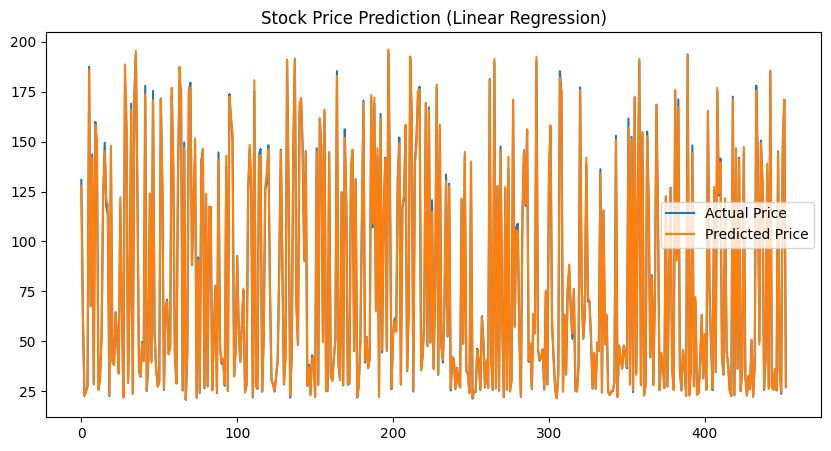

Predicted next day price: [190.5357097]


In [3]:
!pip install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

data = yf.download("AAPL", start="2015-01-01", end="2024-01-01")

data['Prev_Close'] = data['Close'].shift(1)
data = data.dropna()

X = data[['Prev_Close']]
y = data['Close']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.legend()
plt.title("Stock Price Prediction (Linear Regression)")
plt.show()

last_close = data['Close'].iloc[-1].item()
future_price = model.predict([[last_close]])

print("Predicted next day price:", future_price[0])
